In [5]:
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/mushroom/agaricus-lepiota.data"

df = pd.read_csv(url, header=None)

df.head()

,0,1,2,3,4,5,6,7,8,9,...,13,14,15,16,17,18,19,20,21,22
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [7]:
df.columns = [
    'class',
    'cap_shape',
    'cap_surface',
    'cap_color',
    'bruises',
    'odor',
    'gill_attachment',
    'gill_spacing',
    'gill_size',
    'gill_color',
    'stalk_shape',
    'stalk_root',
    'stalk_surface_above_ring',
    'stalk_surface_below_ring',
    'stalk_color_above_ring',
    'stalk_color_below_ring',
    'veil_type',
    'veil_color',
    'ring_number',
    'ring_type',
    'spore_print_color',
    'population',
    'habitat'
]

df.head()

,class,cap_shape,cap_surface,cap_color,bruises,odor,gill_attachment,gill_spacing,gill_size,gill_color,...,stalk_surface_below_ring,stalk_color_above_ring,stalk_color_below_ring,veil_type,veil_color,ring_number,ring_type,spore_print_color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [8]:
mushrooms = df[['class', 'odor', 'cap_color']].copy()

mushrooms.head()

,class,odor,cap_color
0,p,p,n
1,e,a,y
2,e,l,w
3,p,p,w
4,e,n,g


In [9]:
mushrooms['class'] = mushrooms['class'].map({
    'e': 0,
    'p': 1
})

mushrooms['odor'] = mushrooms['odor'].map({
    'a': 0,  # almond
    'l': 1,  # anise
    'c': 2,  # creosote
    'y': 3,  # fishy
    'f': 4,  # foul
    'm': 5,  # musty
    'n': 6,  # none
    'p': 7,  # pungent
    's': 8   # spicy
})

mushrooms['cap_color'] = mushrooms['cap_color'].map({
    'n': 0,  # brown
    'b': 1,  # buff
    'c': 2,  # cinnamon
    'g': 3,  # gray
    'r': 4,  # green
    'p': 5,  # pink
    'u': 6,  # purple
    'e': 7,  # red
    'w': 8,  # white
    'y': 9   # yellow
})

mushrooms.head()

,class,odor,cap_color
0,1,7,0
1,0,0,9
2,0,1,8
3,1,7,8
4,0,6,3


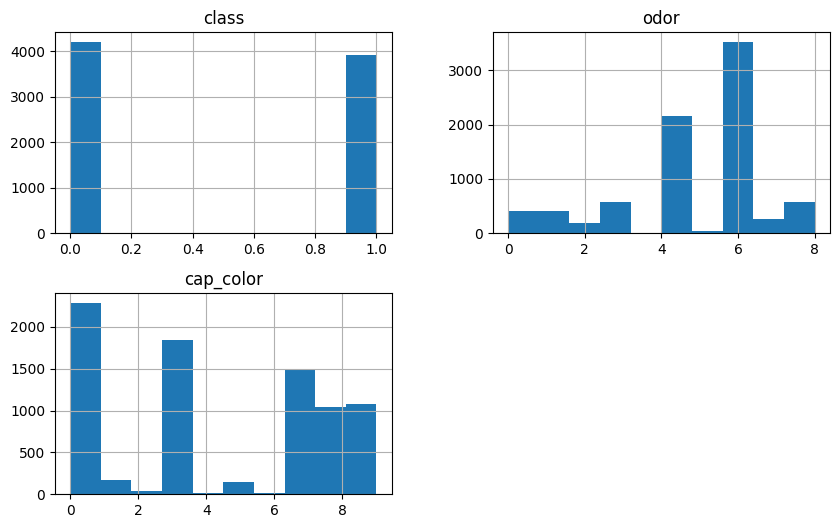

In [10]:
mushrooms.hist(figsize=(10,6))
plt.show()

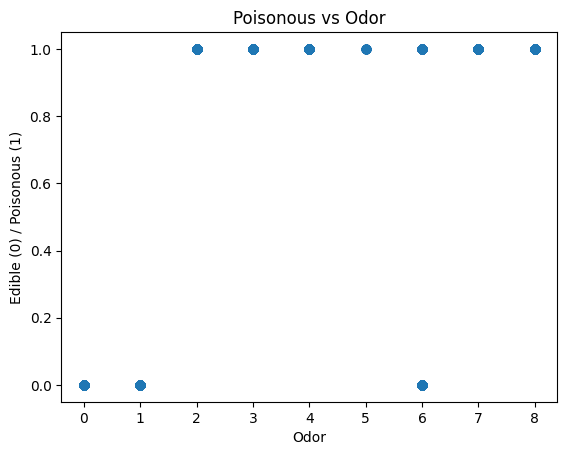

In [ ]:
plt.scatter(mushrooms['odor'], mushrooms['class'])
plt.xlabel("Odor")
plt.ylabel("Edible (0) / Poisonous (1)")
plt.title("Poisonous vs Odor")
plt.show()

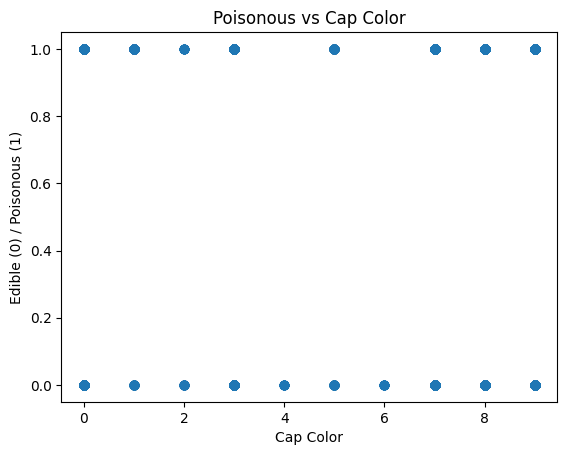

In [ ]:
plt.scatter(mushrooms['cap_color'], mushrooms['class'])
plt.xlabel("Cap Color")
plt.ylabel("Edible (0) / Poisonous (1)")
plt.title("Poisonous vs Cap Color")
plt.show()

## Preliminary Conclusions

  Odor seems to be one of the strongest indicators of whether a mushroom is poisonous or edible. From the scatterplots, certain odor categories are much more closely linked to poisonous mushrooms than others, which makes odor a very useful predictor.
  Cap color may also help provide some insight, but it does not show as clear of a pattern as odor. While there are some visible trends, cap color does not appear to be as reliable for predicting toxicity on its own.
  All in all, based on the visual analysis, odor looks like the better variable for helping predict whether a mushroom is edible or poisonous.

## Predictive Modeling with scikit-learn

In [13]:
X = mushrooms[['odor', 'cap_color']]
y = mushrooms['class']

In [14]:
X_dummies = pd.get_dummies(X, columns=['odor', 'cap_color'])

Since odor and cap color are categorical variables, they need to be turned into binary indicator columns so the model can properly interpret them.

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_dummies, y, test_size=0.3, random_state=42
)

In [16]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [17]:
y_pred = model.predict(X_test)

In [18]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)

Model Accuracy: 0.9868744872846595


In [19]:
X_odor = pd.get_dummies(mushrooms[['odor']], columns=['odor'])

X_train_o, X_test_o, y_train_o, y_test_o = train_test_split(
    X_odor, y, test_size=0.3, random_state=42
)

model_o = DecisionTreeClassifier(random_state=42)
model_o.fit(X_train_o, y_train_o)

y_pred_o = model_o.predict(X_test_o)

from sklearn.metrics import accuracy_score
print("Odor Accuracy:", accuracy_score(y_test_o, y_pred_o))

Odor Accuracy: 0.9840032813781788


In [20]:
X_color = pd.get_dummies(mushrooms[['cap_color']], columns=['cap_color'])

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_color, y, test_size=0.3, random_state=42
)

model_c = DecisionTreeClassifier(random_state=42)
model_c.fit(X_train_c, y_train_c)

y_pred_c = model_c.predict(X_test_c)

print("Cap Color Accuracy:", accuracy_score(y_test_c, y_pred_c))

Cap Color Accuracy: 0.5869565217391305


## Conclusion

Based on the models, odor is clearly the stronger predictor of whether a mushroom is poisonous. The model that used odor on its own performed much better than the one using only cap color, which shows that odor carries more useful information for this classification task.

When both features were used together, the model performed very well overall. However, cap color didn’t add much beyond what odor already provided, so odor is still doing most of the work.

This lines up with the earlier visual analysis, where certain odor categories were strongly associated with poisonous mushrooms.

## Recommendations for Further Analysis

To build on this, it would be useful to include more features from the dataset, like gill size, spore print color, or habitat, to see if the model can be improved further.

It could also be helpful to try other models, such as logistic regression or random forests, and compare their performance to see if they handle the data better.